<a href="https://colab.research.google.com/github/cjatian/ATIAN_CPE018-CPE31S2/blob/main/Activity_6_Face_Detection_using_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.** | **TITLE**
**Name** | LastName, FirstName
**Section** | CPE31Sx
**Date Performed**: |
**Date Submitted**: |
**Instructor**: | Dr. Jonathan V. Taylar / Engr. Verlyn V. Nojor / Engr. Roman M. Richard

<hr>

## 1. Objectives

This activity aims to allow students to perform face detection on still images and videos using Haar cascades.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize OpenCV to detect faces in still images and videos.
* Demonstrate the use of Haar-like features for detection of other human features.

## 3. Procedures and Outputs

Contrary to initial assumptions, conducting face detection on a static image and a video stream shares a remarkable similarity. Essentially, the latter is merely a sequential rendition of the former: when detecting faces in videos, it essentially involves applying face detection to every individual frame obtained from the camera feed. Of course, video face detection introduces additional elements like tracking, which aren't relevant to static images. Nevertheless, it's valuable to recognize that the fundamental principles behind both processes remain consistent.

### Performing face detection on still image

The first and most basic way to perform face detection is to load an image and detect faces in it. To make the result visually meaningful, we will draw rectangles around faces on the original image.

**Before implementing the code below**, check the contents of the `cv2.CascadeClassifier()` function. Provide an explanation of the function, its parameters before running the code below.

In [13]:
from google.colab import files

# This will open a file selection dialog
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving criminal_minds.jpeg to criminal_minds.jpeg
Saving haarcascade_frontalface_default.xml to haarcascade_frontalface_default (1).xml
User uploaded file "criminal_minds.jpeg" with length 373997 bytes
User uploaded file "haarcascade_frontalface_default (1).xml" with length 930127 bytes


In [22]:
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import numpy as np

picPath = '/content/criminal_minds.jpeg' # Changed from .jpg to .jpeg
haarPath = '/content/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)

  if img is None:
    try:
      # Try loading with PIL if OpenCV fails
      pil_img = Image.open(picPath)
      img = np.array(pil_img) # Convert PIL image to NumPy array
      # PIL reads as RGB, OpenCV expects BGR
      if len(img.shape) == 3 and img.shape[2] == 3: # Check if it's a color image
          img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
      elif len(img.shape) == 2: # Grayscale image
          img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
      print(f"Successfully loaded {picPath} using PIL fallback.")
    except Exception as e:
      print(f"Error: Could not load image from {picPath} using OpenCV or PIL. Error: {e}")
      return

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (0,0,255), 4)

  cv2_imshow(img)

Successfully loaded /content/criminal_minds.jpeg using PIL fallback.


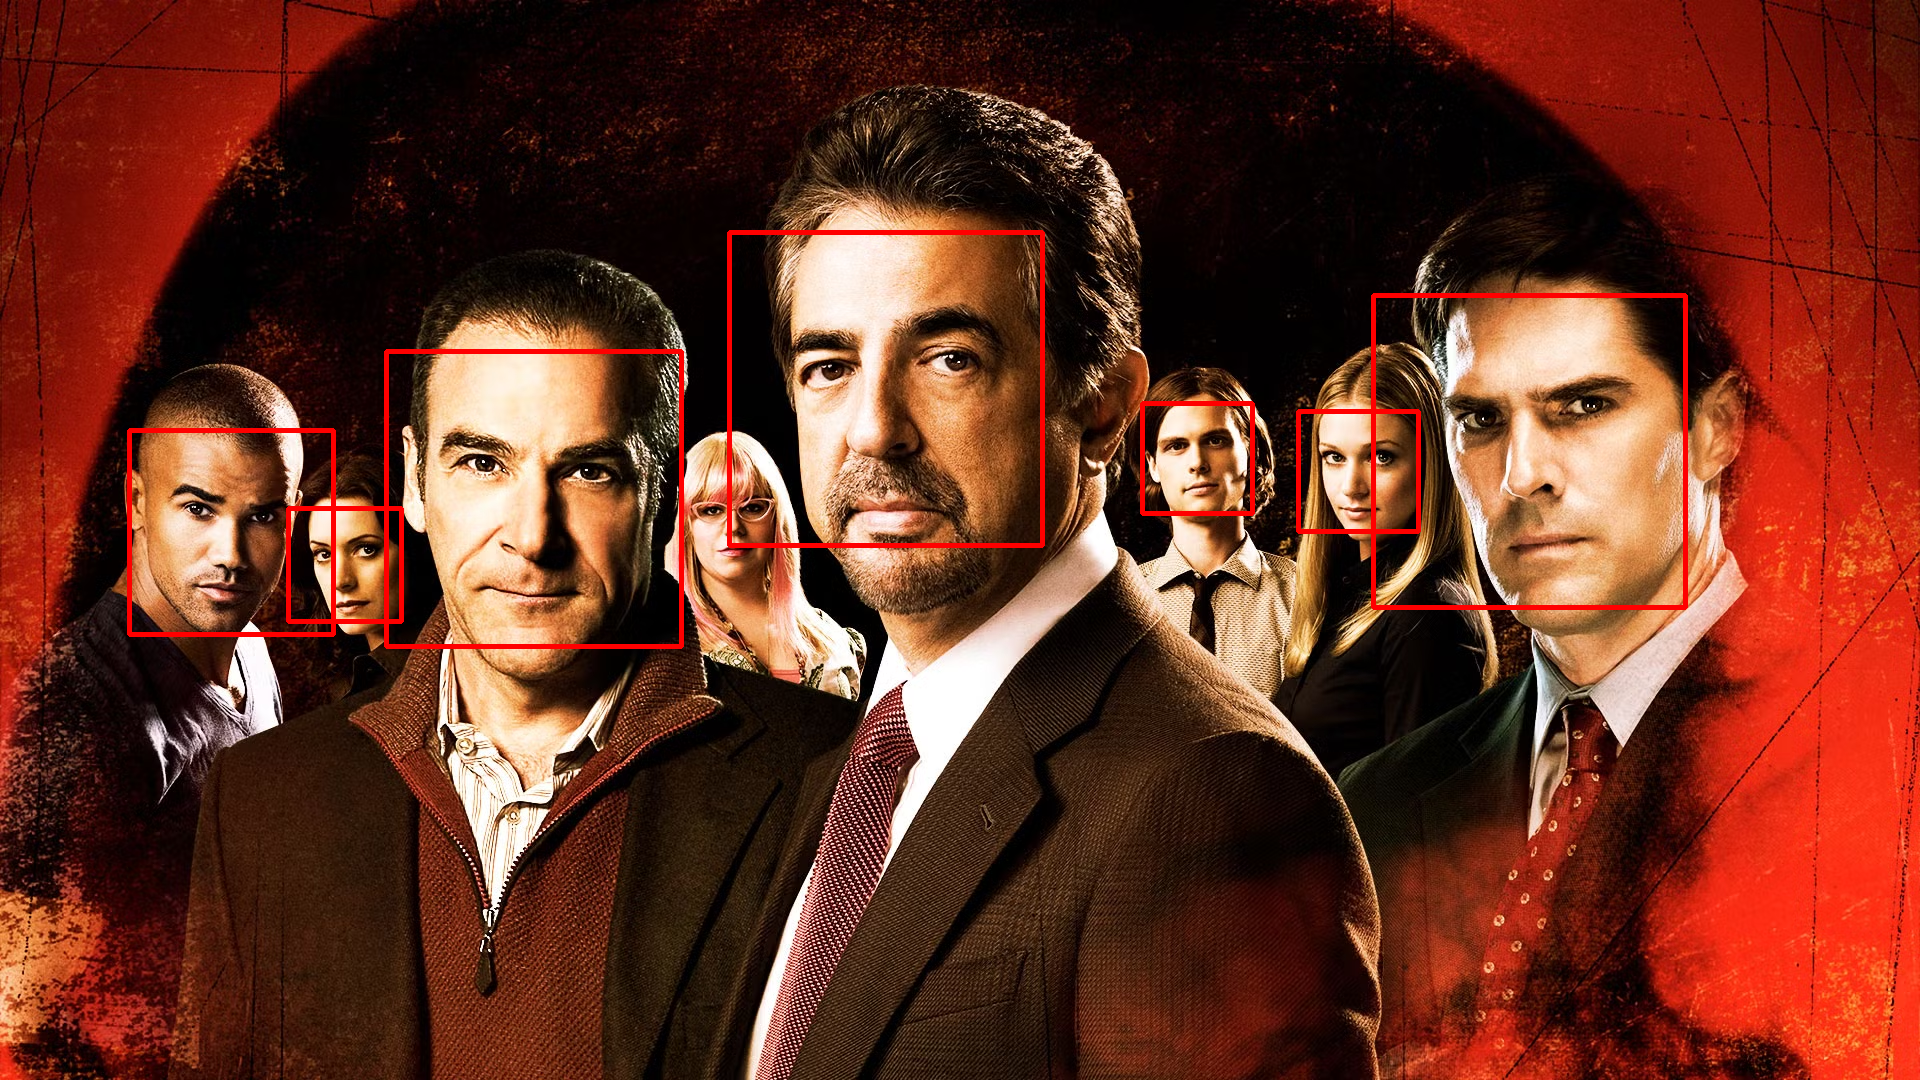

In [23]:
faceDetect(picPath)

**Analysis**:
- Based on your earlier analysis, where do you think the face detection works in the line of code above? ***Face detection works in the line of code "faces = face_cascade.detectMultiScale(gray, 1.3, 5)." This line applies the cascade classifier to detect the faces in grayscale image.***
- Provide an analysis of the parameters of the `detectMultiScale` method.
- Change the color of the border of the detected faces to red. ***I have modified the color of the border of the detected faces from (255,0,0) in cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 4) to (0,0,255).***
- Are you able to make the borders thicker? Demonstrate. ***Yes, I changed the last number from 2 to 4 in this code: cv2.rectangle(img, (x, y), (x+w, y+h), (0,0,255), 4)***

### Performing face detection on video

**Step 1**: Create a file called face_detection.py and include the following codes.

In [19]:
import cv2

**Step 2:** After this, we declare a method, `detect()`, which will perform face detection.

In [ ]:
def detect():
  face_cascade =
  cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
  eye_cascade =
  cv2.CascadeClassifier('/content/haarcascade_eye.xml')
  camera = cv2.VideoCapture(0)

**Step 3:** The first thing we need to do inside the detect() method is to load the Haar cascade files so that OpenCV can operate face detection. As we copied
the cascade files in the local `cascades/` folder, we can use a relative path. Then, we open a VideoCapture object (the camera feed). The VideoCapture  constructor takes a parameter, which indicates the camera to be used; zero indicates the first camera available.

In [ ]:
  while (True):
    ret, frame = camera.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

**Step 4:** Next up, we capture a frame. The read() method returns two values: a Boolean indicating the success of the frame read operation, and the frame
itself. We capture the frame, and then we convert it to grayscale. This is a necessary operation, because face detection in OpenCV happens in the grayscale color space:

In [ ]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

**Step 5:** Much like the single still image example, we call detectMultiScale on the grayscale version of the frame.

In [ ]:
  for (x,y,w,h) in faces:
    img = cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray, 1.03,
    5, 0, (40,40))

**Step 6:** Here we have a further step compared to the still image example: we create a region of interest corresponding to the face rectangle, and within this rectangle, we operate "eye detection". This makes sense as you wouldn't want to go looking for eyes outside a face (well, for human beings at least!).

In [ ]:
  for (ex,ey,ew,eh) in eyes:
    cv2.rectangle(img,(ex,ey),(ex+ew,ey+eh),
    (0,255,0),2)

**Step 7:** Again, we loop through the resulting eye tuples and draw green rectangles around them.

In [ ]:

    cv2.imshow("camera", frame)
    if cv2.waitKey(1000 / 12) & 0xff == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
detect()

**Provide the following**:
- Screenshot of the output for the working code once you've put it all together.
- Summary of the steps you've performed along with observations.

## 4. Supplementary Activity

In your Cameo project, include real-time face detection using Haar cascade. Show screenshots of the working demonstration for this supplementary activity.

Additionally, implement similar steps to detect a smile using Haar cascades.

## 5. Summary, Conclusions and Lessons Learned

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*